In [9]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_regression

1. Linear relationship bw input and output 

In [10]:
df = make_regression(n_samples = 100 , n_features = 3 , random_state = 42 )

In [31]:
df = pd.DataFrame(x, columns = ['f1' , 'f2' , 'f3']) 
df['target'] = y 

In [32]:
df.head()

,f1,f2,f3,target
0,0.852433,0.186454,-0.661786,57.500851
1,-0.485364,-0.772825,-0.236819,-62.430545
2,-0.846794,0.473238,-0.072829,-51.506921
3,2.133033,1.586017,-1.237815,182.876047
4,-1.106335,-0.479174,-0.185659,-99.851830


In [13]:
x = df.iloc[:, 0:3]
y = df.iloc[:, -1]

In [14]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 2)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[75.06,28.2 ,17.74]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['f1','f2','f3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.665e-15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [17]:
y_pred = lr.predict(x_test)

Text(0.5, 1.0, 'f3')

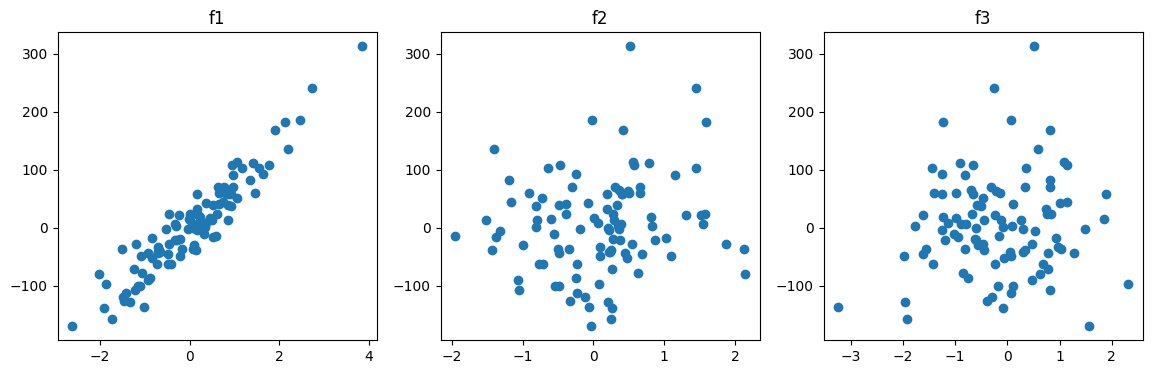

In [23]:
fig , (ax1, ax2 , ax3) = plt.subplots( ncols = 3 , figsize = ( 14, 4))

ax1.scatter(df['f1'] , df['target'])
ax2.scatter(df['f2'] , df['target'])
ax3.scatter(df['f3'] , df['target'])
ax1.set_title('f1')
ax2.set_title('f2')
ax3.set_title('f3')



2. Multicollinearity 

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [25]:
vif = []

for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train , i))

In [26]:
vif

[np.float64(1.0205600109417254),
 np.float64(1.0148083451710819),
 np.float64(1.0182642500288324)]

In [33]:
pd.DataFrame({'vif' : vif} , index = df.columns[0:3]).T

,f1,f2,f3
vif,1.02056,1.014808,1.018264


In [ ]:
#the data is not multicollinear 

<Axes: >

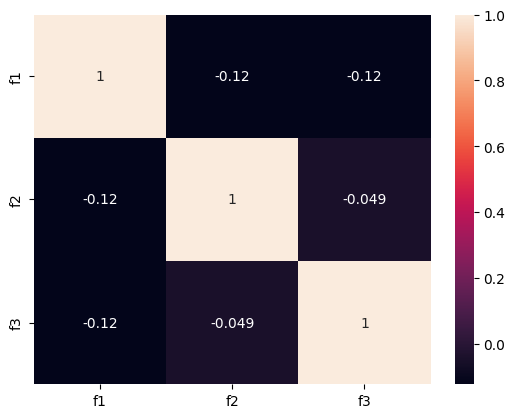

In [35]:
#another technique is plotting a heatmap 

sns.heatmap(df.iloc[:,0:3].corr(), annot = True)

3. Normality of residual

In [36]:
residual = y_pred - y_test

In [38]:
residual.dtype

dtype('float64')

<Axes: xlabel='target', ylabel='Density'>

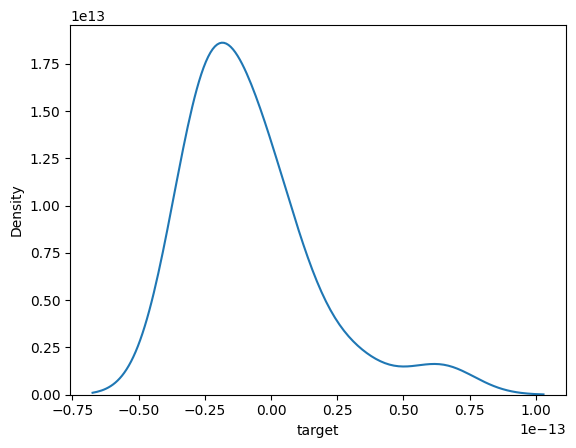

In [39]:
sns.kdeplot(residual)

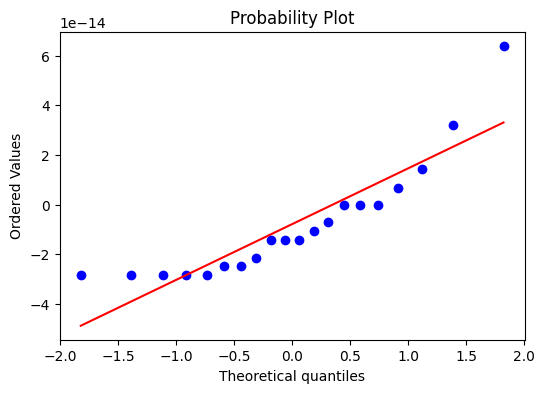

In [ ]:
#plotting QQ plot 
import scipy as sp 

fig,ax = plt.subplots(figsize = (6 ,4))
sp.stats.probplot(residual , plot = ax , fit = True )

plt.show() #not normal

4. Homoscedasticity 

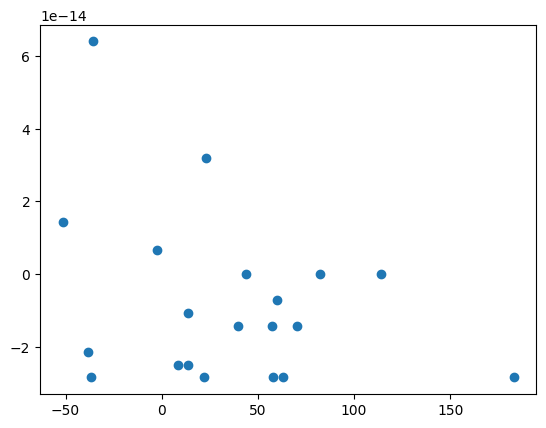

In [ ]:
plt.scatter(y_pred , residual) #for this data it is not homo

5.  No Autocorrelation

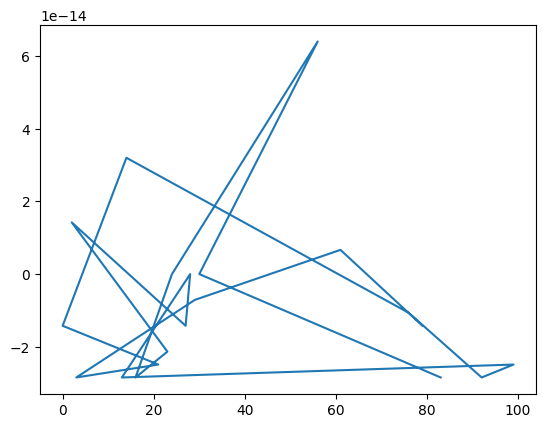

In [42]:
plt.plot(residual)